In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from eval import loadPrices

In [6]:
prices = loadPrices("./prices.txt")
prices.shape

(51, 750)

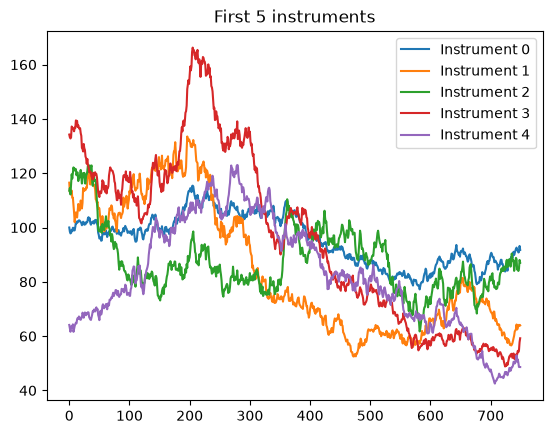

In [30]:
for i in range(5):
    plt.plot(prices[i], label=f"Instrument {i}")

plt.legend()
plt.title("First 5 instruments")
plt.show()

In [ ]:
def instrument_signal_correlation(prices, lookback):
    """
    Checks whether past lookback return predicts next-day return.
    Positive correlation = momentum-like.
    Negative correlation = mean-reversion-like.
    """
    nins, nt = prices.shape
    results = []

    for i in range(nins):
        past_signals = []
        future_returns = []

        for t in range(lookback, nt - 1):
            past_ret = np.log(prices[i, t] / prices[i, t - lookback])
            next_ret = np.log(prices[i, t + 1] / prices[i, t])

            past_signals.append(past_ret)
            future_returns.append(next_ret)

        corr = np.corrcoef(past_signals, future_returns)[0, 1]

        results.append({
            "instrument": i,
            "lookback": lookback,
            "corr": corr,
            "suggested_style": "momentum" if corr > 0 else "mean_reversion"
        })

    return pd.DataFrame(results)

df = instrument_signal_correlation(prices, lookback=80)
df.sort_values("corr")

,instrument,lookback,corr,suggested_style
36,36,80,-0.122748,mean_reversion
29,29,80,-0.113367,mean_reversion
35,35,80,-0.102972,mean_reversion
30,30,80,-0.097718,mean_reversion
33,33,80,-0.095903,mean_reversion
37,37,80,-0.091327,mean_reversion
25,25,80,-0.087742,mean_reversion
42,42,80,-0.085470,mean_reversion
18,18,80,-0.083873,mean_reversion
43,43,80,-0.081420,mean_reversion


In [27]:
mean_reversion_instruments = df[
    df["suggested_style"] == "mean_reversion"
]["instrument"].unique()

mean_reversion_instruments

array([ 0,  2,  5,  6,  8, 10, 11, 12, 14, 15, 16, 17, 18, 21, 22, 24, 25,
       26, 27, 29, 30, 31, 32, 33, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44,
       47, 48])

In [28]:
momentum_instruments = df[
    df["suggested_style"] == "momentum"
]["instrument"].unique()

momentum_instruments

array([ 1,  3,  4,  7,  9, 13, 19, 20, 23, 28, 38, 45, 46, 49, 50])